In [188]:
import pandas as pd

In [189]:
df = pd.read_csv('./dataset.csv')

In [190]:
df = df.drop_duplicates(subset='ID')
df = df.drop(columns=['ID', 'No_Pation'])
df['CLASS'] = df['CLASS'].str.strip()
df.head()

,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,M,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,M,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N


In [191]:
from sklearn.model_selection import train_test_split

In [192]:
y = df['CLASS']
X = df.drop(columns='CLASS')

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0, stratify=y)

In [193]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

In [194]:
le = LabelEncoder()

y_train_encoded =  le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

num_cols = df.select_dtypes(include='number').columns
str_cols = ['Gender']

OH_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

X_train_gender_cols = pd.DataFrame(OH_encoder.fit_transform(X_train[str_cols]), index=X_train.index)
X_test_gender_cols = pd.DataFrame(OH_encoder.transform(X_test[str_cols]), index=X_test.index)

X_train_gender_cols.columns = X_train_gender_cols.columns.astype(str)
X_test_gender_cols.columns = X_test_gender_cols.columns.astype(str)

X_train = X_train.drop(columns=str_cols)
X_test = X_test.drop(columns=str_cols)

X_train = pd.concat([X_train, X_train_gender_cols], axis=1)
X_test = pd.concat([X_test, X_test_gender_cols], axis=1)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), index=X_test.index)

X_train_scaled.columns = X_train.columns
X_test_scaled.columns = X_test.columns
print(X_train_scaled.head())

          AGE      Urea        Cr     HbA1c      Chol        TG       HDL  \
16  -0.395279  0.337530 -0.278857 -1.058223  0.364360 -1.047600 -0.142890   
609  0.995733  0.001072 -0.075113  1.506252 -0.950833  1.906967 -0.479628   
133 -2.365880 -0.073697 -0.054739 -0.907371 -0.022461 -0.841467  0.867327   
377  0.068391 -0.260618 -0.238108  1.053697 -1.105562  0.464039 -0.479628   
243  0.416144 -1.120456  0.210128 -0.454817  0.519089 -0.291781 -0.311259   

          LDL      VLDL       BMI         0         1  
16   1.368026 -0.421189 -1.666747  1.147433 -1.147433  
609 -0.063042 -0.275771  0.092449 -0.871511  0.871511  
133  0.026400 -0.372717 -0.884882 -0.871511  0.871511  
377  0.831376 -0.275771  0.287915  1.147433 -1.147433  
243  1.010259 -0.275771  0.678848 -0.871511  0.871511  


In [195]:
import numpy as np
from tensorflow.keras import Sequential, layers, callbacks
from sklearn.utils.class_weight import compute_class_weight

In [196]:
classes = np.unique(y_train_encoded)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_encoded)

class_weights = dict(zip(classes, weights))

input_shape = X_train.shape[1]
model = Sequential([
    layers.Dense(512, activation='relu', input_shape=[input_shape]),
    layers.BatchNormalization(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dense(3, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

callback = callbacks.EarlyStopping(patience=10, min_delta=0.001, restore_best_weights=True)

model.fit(X_train_scaled, 
          y_train_encoded, 
          epochs=100, 
          verbose=False, 
          validation_data=(X_test_scaled, y_test_encoded),
          class_weight=class_weights,
          callbacks=[callback])
y_preds = model.predict(X_test_scaled)

/home/erick/Desktop/python311/tf_env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, recall_score, classification_report

              precision    recall  f1-score   support

           0       0.81      0.84      0.82        25
           1       0.64      0.69      0.67        13
           2       0.98      0.97      0.98       162

    accuracy                           0.94       200
   macro avg       0.81      0.83      0.82       200
weighted avg       0.94      0.94      0.94       200

0.935


<Axes: >

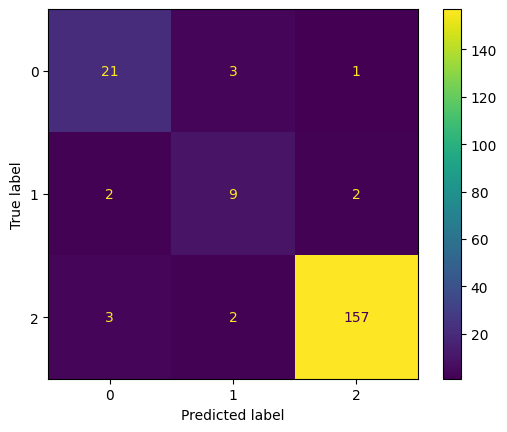

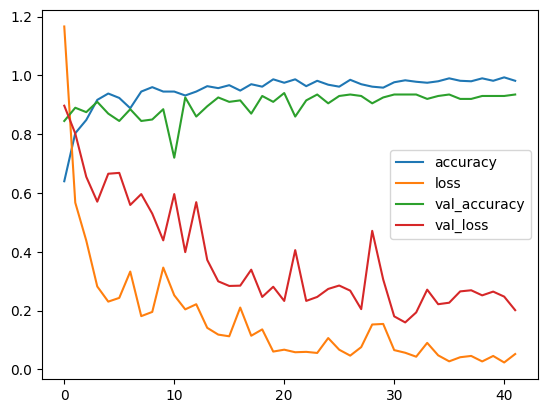

In [219]:
y_preds_final = np.argmax(y_preds, axis=1)
m = confusion_matrix(y_test_encoded, y_preds_final)
lol = ConfusionMatrixDisplay(m)
print(classification_report(y_test_encoded, y_preds_final))
print(recall_score(y_test_encoded, y_preds_final, average='weighted'))

lol.plot()
xd = pd.DataFrame(model.history.history)
xd.plot()

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

{'C': 100, 'gamma': 'scale', 'kernel': 'linear'}
              precision    recall  f1-score   support

           0       0.74      0.92      0.82        25
           1       0.86      0.92      0.89        13
           2       0.99      0.95      0.97       162

    accuracy                           0.94       200
   macro avg       0.86      0.93      0.89       200
weighted avg       0.95      0.94      0.95       200

0.945


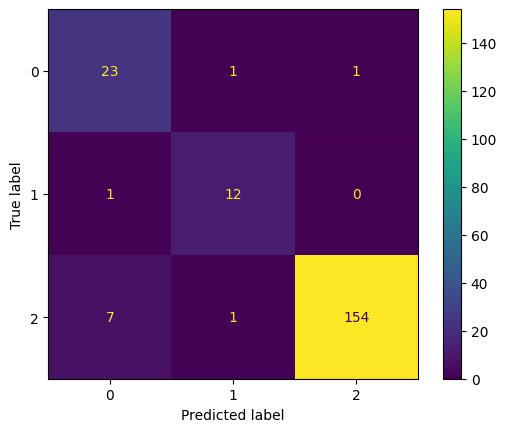

In [217]:
param_grid_svc = {
    'kernel': ['linear', 'rbf'],
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto']
}

grid_svm = GridSearchCV(
    estimator=SVC(class_weight='balanced'),
    param_grid=param_grid_svc,
    cv=5,
    scoring='f1_weighted',
)

grid_svm.fit(X_train_scaled, y_train_encoded)

print(grid_svm.best_params_)
best_svm = grid_svm.best_estimator_

y_preds_svm = best_svm.predict(X_test_scaled)
m = confusion_matrix(y_test_encoded, y_preds_svm)
print(classification_report(y_test_encoded, y_preds_svm))
m_dis = ConfusionMatrixDisplay(m)
print(recall_score(y_test_encoded, y_preds_svm, average='weighted'))
m_dis.plot()


In [203]:
from sklearn.neighbors import KNeighborsClassifier

{'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}
              precision    recall  f1-score   support

           0       0.84      0.64      0.73        25
           1       0.62      0.62      0.62        13
           2       0.95      0.99      0.97       162

    accuracy                           0.92       200
   macro avg       0.80      0.75      0.77       200
weighted avg       0.92      0.92      0.92       200

0.92


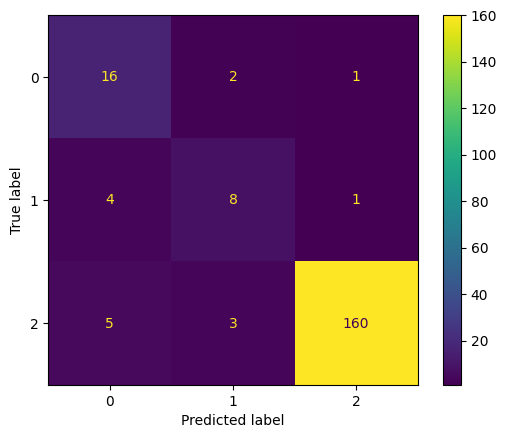

In [218]:
param_grid_knn = {
    'n_neighbors': [1, 3, 5, 7, 9, 11, 13],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid_knn,
    cv=5,
    scoring='f1_weighted',
)

grid_knn.fit(X_train_scaled, y_train_encoded)

print(grid_knn.best_params_)

y_preds_knn = grid_knn.predict(X_test_scaled)
m = confusion_matrix(y_preds_knn, y_test_encoded)
m_dis = ConfusionMatrixDisplay(m)
print(classification_report(y_test_encoded, y_preds_knn))
print(recall_score(y_test_encoded, y_preds_knn, average='weighted'))
m_dis.plot()